In [1]:
import pyteomics
import lxml
from pyteomics import mzml, mass
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from matplotlib import pyplot
import matplotlib
import seaborn as sns
import re
import statistics

In [2]:
fileslist = []
dir = 'D:\\yuming\\2023\\20230312\\quantification\\mzml'
for file in os.listdir(dir):
    if file.endswith(".mzML"):
        fileslist.append(os.path.join(dir, file))
print(fileslist)

['D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_5_3.mzML', 'D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_6_1.mzML', 'D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_6_2.mzML', 'D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_6_3.mzML', 'D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_1_1.mzML', 'D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_1_2.mzML', 'D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_1_3.mzML', 'D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_2_1.mzML', 'D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_2_2.mzML', 'D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_2_3.mzML', 'D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_3_1.mzML', 'D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_3_2.mzML', 'D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_3_3.mzML', 'D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_4_1.mzML', 'D:\\yuming\\2023\\20230312\\quantification\\mzml\\MIX_4_2.mzML', 'D:\\yumi

In [3]:
mix1=[item for item in fileslist if 'MIX_1' in item]
mix2=[item for item in fileslist if 'MIX_2' in item]
mix3=[item for item in fileslist if 'MIX_3' in item]
mix4=[item for item in fileslist if 'MIX_4' in item]
mix5=[item for item in fileslist if 'MIX_5' in item]
mix6=[item for item in fileslist if 'MIX_6' in item]

In [4]:
import itertools

In [5]:
def baselist(files=mix1):  
    tar_list1 = []
    tar_list2 = []
    tar_list3 = []
    # Loop through the data and populate the lists
    for num in [0, 1, 2]:
        tmp_ms = pyteomics.mzml.read(files[num], use_index=True)
        for i in range(168):
            my_list=tmp_ms.get_by_index(i)['intensity array'].tolist()
            top_5_values = sorted(my_list, reverse=True)[:10]
            if num == 0:
                tar_list1.append(top_5_values)
            elif num == 1:
                tar_list2.append(top_5_values)
            elif num == 2:
                tar_list3.append(top_5_values)
    list1=list(itertools.chain(*tar_list1))
    list2=list(itertools.chain(*tar_list2))
    list3=list(itertools.chain(*tar_list3))
    list11=sorted(list1, reverse=True)[:1300]
    list22=sorted(list2, reverse=True)[:1300]
    list33=sorted(list3, reverse=True)[:1300]
        # Combine the lists into a single dataframe
    df = pd.DataFrame({"%s_1" %files[0] : list11, "%s_2" %files[1]: list22, "%s_3" %files[2]: list33})         
    return(df)

In [6]:
def baselist2(files=mix1):  
    tar_list1,tar_list2,tar_list3 = [],[],[]
    # Loop through the data and populate the lists
    for num in [0, 1, 2]:
        tmp_ms = pyteomics.mzml.read(files[num], use_index=True)
        for i in range(168):
            my_list=tmp_ms.get_by_index(i)['intensity array'].tolist()
            top_5_values = sorted(my_list, reverse=True)[:20]
            if num == 0:
                tar_list1.append(top_5_values)
            elif num == 1:
                tar_list2.append(top_5_values)
            elif num == 2:
                tar_list3.append(top_5_values)
    list1=list(itertools.chain(*tar_list1))
    list2=list(itertools.chain(*tar_list2))
    list3=list(itertools.chain(*tar_list3))
        # Combine the lists into a single dataframe
    df = pd.DataFrame({"%s_1" %files[0] : list1, "%s_2" %files[1]: list2, "%s_3" %files[2]: list3})         
    return(df)

In [7]:
dfdf=pd.concat([baselist2(files=mix1),baselist2(files=mix3),baselist2(files=mix4),baselist2(files=mix5),baselist2(files=mix6)],axis=1)

In [8]:
dfdf

,D:\yuming\2023\20230312\quantification\mzml\MIX_1_1.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_1_2.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_1_3.mzML_3,D:\yuming\2023\20230312\quantification\mzml\MIX_3_1.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_3_2.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_3_3.mzML_3,D:\yuming\2023\20230312\quantification\mzml\MIX_4_1.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_4_2.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_4_3.mzML_3,D:\yuming\2023\20230312\quantification\mzml\MIX_5_3.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_5_1.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_5_2.mzML_3,D:\yuming\2023\20230312\quantification\mzml\MIX_6_1.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_6_2.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_6_3.mzML_3
0,4.042084e+06,4.627906e+06,5.142828e+06,2.252323e+06,2.411454e+06,2.470686e+06,939038.500000,923194.500000,1.068288e+06,479297.125000,532568.562500,523062.406250,755443.000000,577203.500000,475291.125000
1,1.547475e+06,1.970765e+06,2.133318e+06,7.974768e+05,8.312834e+05,8.828059e+05,326542.031250,300828.218750,3.460616e+05,238510.968750,390052.531250,319146.312500,328520.750000,272006.562500,261722.734375
2,5.394164e+05,6.272470e+05,6.436566e+05,4.618038e+05,4.634362e+05,4.728744e+05,261347.421875,250144.656250,2.764201e+05,222317.734375,239478.140625,248639.781250,308600.781250,264306.125000,259777.765625
3,3.893326e+05,3.965616e+05,3.759669e+05,3.733042e+05,3.852349e+05,4.248938e+05,247798.781250,240358.000000,2.628931e+05,207911.953125,238404.375000,235801.218750,281465.781250,249761.875000,233956.109375
4,2.825048e+05,2.608563e+05,2.734358e+05,3.180461e+05,3.348907e+05,2.586722e+05,184383.328125,141331.062500,1.360020e+05,188215.796875,217828.156250,205261.718750,162651.234375,129920.210938,122088.515625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3355,7.169829e+05,7.321398e+05,6.715272e+05,4.113959e+05,4.199473e+05,4.298300e+05,281109.093750,296138.843750,2.849102e+05,140496.828125,141338.406250,141291.250000,47259.531250,47799.488281,48131.343750
3356,7.027314e+05,6.955259e+05,6.414128e+05,4.090913e+05,4.016953e+05,4.156436e+05,280837.718750,286365.187500,2.766926e+05,135983.031250,124814.859375,129598.679688,47063.519531,44411.433594,47971.019531
3357,6.808372e+05,6.910123e+05,6.334165e+05,4.067241e+05,3.893598e+05,3.869936e+05,278750.031250,236631.687500,2.609220e+05,130863.968750,112337.250000,123719.453125,46593.347656,44159.863281,44804.281250
3358,6.515441e+05,6.792509e+05,6.051024e+05,3.884840e+05,3.849236e+05,3.850977e+05,274294.687500,230748.968750,2.491321e+05,120928.593750,110671.929688,122837.929688,45393.171875,42719.406250,44789.894531


In [9]:
dfdf_log2=np.log2(dfdf)

In [10]:
df_all=pd.concat([baselist(files=mix1),baselist(files=mix3),baselist(files=mix4),baselist(files=mix5),baselist(files=mix6)],axis=1)

In [11]:
df_all

,D:\yuming\2023\20230312\quantification\mzml\MIX_1_1.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_1_2.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_1_3.mzML_3,D:\yuming\2023\20230312\quantification\mzml\MIX_3_1.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_3_2.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_3_3.mzML_3,D:\yuming\2023\20230312\quantification\mzml\MIX_4_1.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_4_2.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_4_3.mzML_3,D:\yuming\2023\20230312\quantification\mzml\MIX_5_3.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_5_1.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_5_2.mzML_3,D:\yuming\2023\20230312\quantification\mzml\MIX_6_1.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_6_2.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_6_3.mzML_3
0,8.470990e+07,8.104358e+07,6.997263e+07,5.314726e+07,7.209880e+07,5.761705e+07,4.370186e+07,4.657294e+07,4.334898e+07,2.079992e+07,2.004664e+07,1.684521e+07,7.696090e+06,7.821239e+06,7.806132e+06
1,5.557970e+07,5.560679e+07,5.090558e+07,4.644272e+07,4.813440e+07,4.839456e+07,3.288294e+07,3.210332e+07,3.206251e+07,1.994657e+07,1.538250e+07,1.144569e+07,7.605863e+06,6.093494e+06,7.696200e+06
2,5.232594e+07,5.204505e+07,5.020261e+07,2.950903e+07,2.863456e+07,3.310448e+07,1.688127e+07,1.649857e+07,1.648304e+07,1.144195e+07,1.217357e+07,1.088361e+07,6.347666e+06,5.915684e+06,5.912022e+06
3,4.706229e+07,4.622894e+07,3.763714e+07,2.325032e+07,2.614368e+07,2.596867e+07,1.449584e+07,1.397655e+07,1.344239e+07,8.730090e+06,8.502241e+06,8.546822e+06,6.342464e+06,5.604406e+06,5.589871e+06
4,3.901752e+07,4.200246e+07,3.477704e+07,2.296086e+07,2.365464e+07,2.349589e+07,1.342642e+07,1.380094e+07,1.266695e+07,8.353477e+06,8.256642e+06,8.321879e+06,5.917035e+06,5.076634e+06,5.241996e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,9.637438e+04,1.001348e+05,1.078347e+05,6.359440e+04,6.641556e+04,6.448020e+04,4.654865e+04,4.615673e+04,4.623082e+04,3.938535e+04,4.223515e+04,4.110659e+04,3.971644e+04,3.668059e+04,3.684505e+04
1296,9.559888e+04,9.963088e+04,1.076705e+05,6.295920e+04,6.602276e+04,6.329404e+04,4.654061e+04,4.597375e+04,4.610111e+04,3.938465e+04,4.217724e+04,4.100003e+04,3.953582e+04,3.638427e+04,3.660653e+04
1297,9.525898e+04,9.953198e+04,1.066876e+05,6.278522e+04,6.596954e+04,6.282504e+04,4.628981e+04,4.568637e+04,4.601972e+04,3.915776e+04,4.140239e+04,4.074507e+04,3.952609e+04,3.610623e+04,3.619416e+04
1298,9.400532e+04,9.903791e+04,1.065630e+05,6.272122e+04,6.573666e+04,6.271220e+04,4.627641e+04,4.564285e+04,4.592207e+04,3.905146e+04,4.138497e+04,4.062913e+04,3.866273e+04,3.589437e+04,3.599149e+04


In [12]:
k=np.log2(df_all)

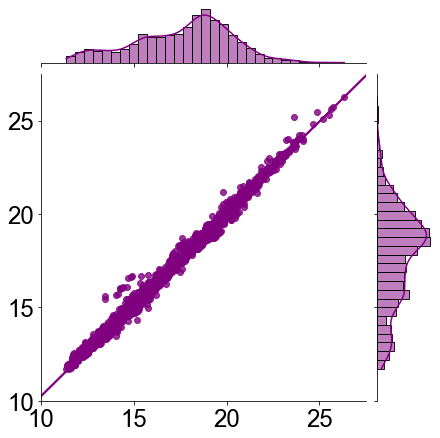

In [13]:
#sns.set_theme(style="darkgrid")
#sns.set(font_scale=2)
plt.rcParams['font.family'] = 'Arial'
g=sns.jointplot(x=dfdf_log2.iloc[:,0].tolist(), 
                  y=dfdf_log2.iloc[:,1].tolist(),
                  xlim = (10,27.5), ylim = (10,27.5),
                  kind="reg", truncate=False,
                  color="purple", height=6)

g.ax_joint.tick_params(labelsize=24)
# plt.xlabel('Log2(intensity)', fontsize=22)
# plt.ylabel('Log2(intensity)', fontsize=22)

plt.savefig(r'D:\\project7_SMAD\\figure2\\quantification\\jointplot_meta.svg',dpi=800,bbox_inches='tight')

In [14]:
from scipy.stats import spearmanr

# Two example lists
list1 = dfdf_log2.iloc[:,0].tolist()
list2 = dfdf_log2.iloc[:,1].tolist()

# Calculate Spearman's rho and p-value
rho, pval = spearmanr(list1, list2)

# Print the results
print("Spearman's rho =", rho)
print("p-value =", pval)

Spearman's rho = 0.9968477704883181
p-value = 0.0


In [15]:
dfnew2=np.log2(df_all)

In [16]:
dfnew2

,D:\yuming\2023\20230312\quantification\mzml\MIX_1_1.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_1_2.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_1_3.mzML_3,D:\yuming\2023\20230312\quantification\mzml\MIX_3_1.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_3_2.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_3_3.mzML_3,D:\yuming\2023\20230312\quantification\mzml\MIX_4_1.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_4_2.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_4_3.mzML_3,D:\yuming\2023\20230312\quantification\mzml\MIX_5_3.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_5_1.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_5_2.mzML_3,D:\yuming\2023\20230312\quantification\mzml\MIX_6_1.mzML_1,D:\yuming\2023\20230312\quantification\mzml\MIX_6_2.mzML_2,D:\yuming\2023\20230312\quantification\mzml\MIX_6_3.mzML_3
0,26.336027,26.272195,26.060287,25.663492,26.103472,25.779992,25.381191,25.472989,25.369495,24.310075,24.256857,24.005835,22.875694,22.898966,22.896176
1,25.728055,25.728758,25.601321,25.468949,25.520565,25.528342,24.970836,24.936219,24.934384,24.249637,23.874786,23.448302,22.858681,22.538838,22.875715
2,25.641023,25.633258,25.581259,24.814653,24.771254,24.980523,24.008920,23.975838,23.974479,23.447829,23.537249,23.375653,22.597795,22.496113,22.495220
3,25.488068,25.462293,25.165654,24.470747,24.639959,24.630269,23.789136,23.736505,23.680286,23.057565,23.019412,23.026957,22.596612,22.418130,22.414384
4,25.217619,25.323971,25.051632,24.452674,24.495620,24.485905,23.678571,23.718263,23.594566,22.993945,22.977124,22.988478,22.496443,22.275441,22.321685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,16.556362,16.611584,16.718462,15.956612,16.019234,15.976569,15.506452,15.494253,15.496567,15.265371,15.366157,15.327082,15.277449,15.162729,15.169183
1296,16.544706,16.604305,16.716263,15.942130,16.010676,15.949782,15.506202,15.488523,15.492514,15.265346,15.364177,15.323337,15.270873,15.151027,15.159813
1297,16.539568,16.602873,16.703033,15.938137,16.009512,15.939052,15.498407,15.479476,15.489965,15.257011,15.337427,15.314338,15.270518,15.139960,15.143469
1298,16.520455,16.595693,16.701347,15.936666,16.004410,15.936458,15.497989,15.478101,15.486900,15.253089,15.336819,15.310227,15.238656,15.131470,15.135368


In [17]:
# calculate cv of targeted m/z 

cv = lambda x: np.std(x, ddof=1) / np.mean(x) * 100 

META1=dfnew2.iloc[:,:3].T
META2=dfnew2.iloc[:,3:6].T
META3=dfnew2.iloc[:,6:9].T
META4=dfnew2.iloc[:,9:12].T
META5=dfnew2.iloc[:,12:15].T


In [18]:

df=dfdf
#df=df_all
META1=df.iloc[:,:3].T
META2=df.iloc[:,3:6].T
META3=df.iloc[:,6:9].T
META4=df.iloc[:,9:12].T
META5=df.iloc[:,12:15].T
newdf={'Meta1':META1.apply(cv).tolist(),
    'Meta2':META2.apply(cv).tolist(),
    'Meta3':META3.apply(cv).tolist(),
    'Meta4':META4.apply(cv).tolist(),
    'Meta5':META5.apply(cv).tolist()}

In [19]:
uk=pd.DataFrame.from_dict(newdf, orient='index')
um=uk.transpose()

In [22]:
um

,Meta1,Meta2,Meta3,Meta4,Meta5
0,11.961770,4.748474,8.147797,5.553187,23.529289
1,16.054182,5.132655,6.991942,24.001909,12.513754
2,9.288387,1.282378,5.020273,5.642472,9.718905
3,2.697901,6.846571,4.586426,7.434288,9.485606
4,3.993006,13.176046,17.237058,7.293834,15.567498
...,...,...,...,...,...
3355,4.462291,2.194402,2.719261,0.335262,0.921905
3356,4.929685,1.707005,1.725124,4.305751,3.979335
3357,4.598829,2.731903,8.170116,7.639623,2.790281
3358,5.806089,0.519787,8.695839,5.537961,3.165567


In [27]:
alli=[item for sublist in um.values.tolist() for item in sublist]

goodi=[item for item in alli if item<20] 

In [30]:
len(goodi)/len(alli)

0.9338690476190477

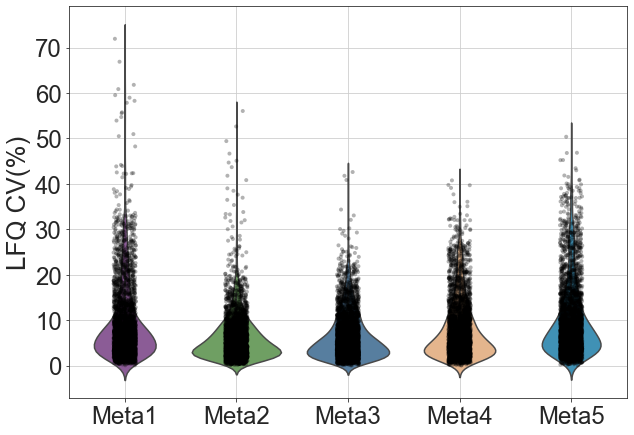

In [21]:
matplotlib.rcParams['font.family'] = "Arial"
plt.figure(figsize=(10, 7.2))
sns.set_style("ticks")

custom_palette = ['#9152A0', '#69A959', '#4B7FAB','#F3B47E', '#2D99C8']
sns.violinplot(data=um,palette=custom_palette)
sns.stripplot(data=um, jitter=True,alpha=0.3,size=4, color="black")
plt.ylabel('LFQ CV(%)', fontsize=26)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.grid()
plt.savefig(r'D:\\project7_SMAD\\figure2\\figure2\\CV_meta.svg',dpi=800,bbox_inches='tight')

In [23]:
dfnew2.columns=[item.split('\\')[-1].split('.')[0] for item in df_all.columns]

In [24]:
dfnew2.T

,0,1,2,3,4,5,6,7,8,9,...,1290,1291,1292,1293,1294,1295,1296,1297,1298,1299
MIX_1_1,26.336027,25.728055,25.641023,25.488068,25.217619,24.856474,24.670240,24.117824,24.111300,24.035186,...,16.592793,16.589285,16.564192,16.560790,16.560659,16.556362,16.544706,16.539568,16.520455,16.518115
MIX_1_2,26.272195,25.728758,25.633258,25.462293,25.323971,25.173834,25.092691,24.831311,24.254990,24.215558,...,16.640420,16.630422,16.629140,16.621402,16.614437,16.611584,16.604305,16.602873,16.595693,16.595210
MIX_1_3,26.060287,25.601321,25.581259,25.165654,25.051632,24.911184,24.760275,24.309042,24.188278,24.159004,...,16.744667,16.727716,16.725428,16.723607,16.722573,16.718462,16.716263,16.703033,16.701347,16.699448
MIX_3_1,25.663492,25.468949,24.814653,24.470747,24.452674,24.327139,24.293323,24.212453,24.203156,24.188098,...,16.022975,15.991820,15.979084,15.963562,15.958825,15.956612,15.942130,15.938137,15.936666,15.936187
MIX_3_2,26.103472,25.520565,24.771254,24.639959,24.495620,24.465014,24.306264,24.219826,24.158533,24.105018,...,16.062168,16.047469,16.046349,16.029717,16.028851,16.019234,16.010676,16.009512,16.004410,16.001173
MIX_3_3,25.779992,25.528342,24.980523,24.630269,24.485905,24.261120,24.257590,24.245038,24.140655,23.903770,...,16.048607,16.012944,16.006957,15.991513,15.986627,15.976569,15.949782,15.939052,15.936458,15.925058
MIX_4_1,25.381191,24.970836,24.008920,23.789136,23.678571,23.542096,23.432388,23.283550,23.267783,23.265920,...,15.543394,15.540169,15.538671,15.531746,15.508352,15.506452,15.506202,15.498407,15.497989,15.479489
MIX_4_2,25.472989,24.936219,23.975838,23.736505,23.718263,23.622133,23.611972,23.378228,23.312630,23.274560,...,15.541647,15.521906,15.519562,15.511450,15.508361,15.494253,15.488523,15.479476,15.478101,15.477605
MIX_4_3,25.369495,24.934384,23.974479,23.680286,23.594566,23.571745,23.432910,23.323698,23.261002,23.257172,...,15.566859,15.555722,15.541153,15.536413,15.532210,15.496567,15.492514,15.489965,15.486900,15.479393
MIX_5_3,24.310075,24.249637,23.447829,23.057565,22.993945,22.921480,22.690480,22.594241,22.529823,22.307661,...,15.308497,15.290189,15.289067,15.281370,15.279054,15.265371,15.265346,15.257011,15.253089,15.252193


In [25]:
name=['mix1']*3+['mix2']*3+['mix3']*3+['mix4']*3+['mix5']*3
lk=dfnew2.T
woca=lk.sort_values(by=lk.columns[1],ascending=True)
woca['name']=name

In [26]:
woca

,0,1,2,3,4,5,6,7,8,9,...,1291,1292,1293,1294,1295,1296,1297,1298,1299,name
MIX_6_2,22.898966,22.538838,22.496113,22.418130,22.275441,22.151035,22.081842,21.882602,21.856201,21.508682,...,15.198196,15.193265,15.193056,15.175422,15.162729,15.151027,15.139960,15.131470,15.115356,mix1
MIX_6_1,22.875694,22.858681,22.597795,22.596612,22.496443,22.483129,22.210694,22.183297,22.072863,21.943978,...,15.297026,15.287714,15.284028,15.279861,15.277449,15.270873,15.270518,15.238656,15.225392,mix1
MIX_6_3,22.896176,22.875715,22.495220,22.414384,22.321685,22.200141,22.151395,22.066737,21.785228,21.645523,...,15.187519,15.182159,15.179871,15.179071,15.169183,15.159813,15.143469,15.135368,15.127929,mix1
MIX_5_2,24.005835,23.448302,23.375653,23.026957,22.988478,22.756468,22.604125,22.595396,22.361756,22.261144,...,15.340854,15.334983,15.333014,15.331138,15.327082,15.323337,15.314338,15.310227,15.305205,mix2
MIX_5_1,24.256857,23.874786,23.537249,23.019412,22.977124,22.738992,22.669440,22.555076,22.537030,22.416678,...,15.382018,15.378850,15.368520,15.366680,15.366157,15.364177,15.337427,15.336819,15.336002,mix2
MIX_5_3,24.310075,24.249637,23.447829,23.057565,22.993945,22.921480,22.690480,22.594241,22.529823,22.307661,...,15.290189,15.289067,15.281370,15.279054,15.265371,15.265346,15.257011,15.253089,15.252193,mix2
MIX_4_3,25.369495,24.934384,23.974479,23.680286,23.594566,23.571745,23.432910,23.323698,23.261002,23.257172,...,15.555722,15.541153,15.536413,15.532210,15.496567,15.492514,15.489965,15.486900,15.479393,mix3
MIX_4_2,25.472989,24.936219,23.975838,23.736505,23.718263,23.622133,23.611972,23.378228,23.312630,23.274560,...,15.521906,15.519562,15.511450,15.508361,15.494253,15.488523,15.479476,15.478101,15.477605,mix3
MIX_4_1,25.381191,24.970836,24.008920,23.789136,23.678571,23.542096,23.432388,23.283550,23.267783,23.265920,...,15.540169,15.538671,15.531746,15.508352,15.506452,15.506202,15.498407,15.497989,15.479489,mix3
MIX_3_1,25.663492,25.468949,24.814653,24.470747,24.452674,24.327139,24.293323,24.212453,24.203156,24.188098,...,15.991820,15.979084,15.963562,15.958825,15.956612,15.942130,15.938137,15.936666,15.936187,mix4


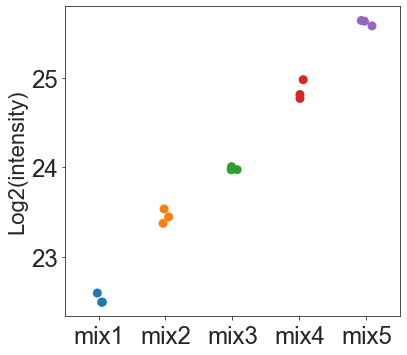

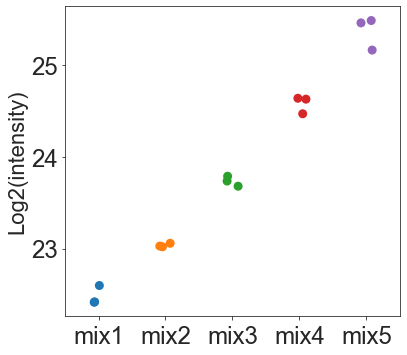

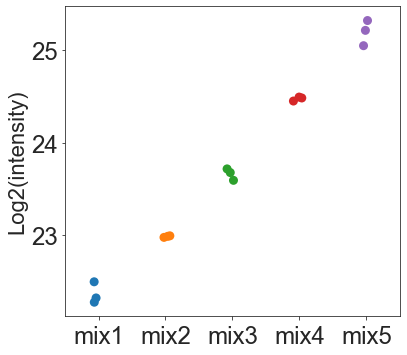

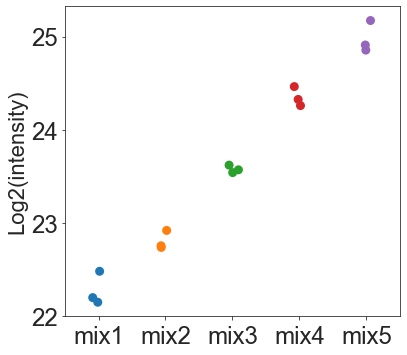

In [44]:
import seaborn as sns
plt.rcParams['font.family'] = 'Arial'

for number in [2,3,4,5]: 
    plt.figure(figsize=(6, 5.7), edgecolor='#04253a')
    g=sns.stripplot(x="name", y=woca.iloc[:,number], data=woca, jitter=True,size=9) 
    g.tick_params(axis='x', which='major',labelsize=24, pad=5)
    g.tick_params(axis='y', which='major',labelsize=24)
    plt.xlabel('')
    plt.xlabel('')
    plt.ylabel('Log2(intensity)', fontsize=22)
    plt.savefig(r'D:\\project7_SMAD\\figure2\\quantification\\%s.svg' % number,dpi=800,bbox_inches='tight')
    plt.show()

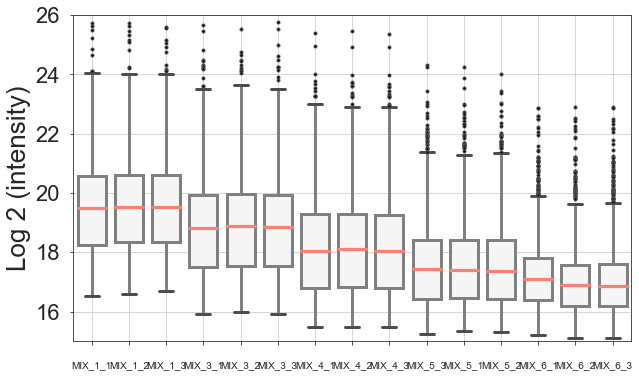

In [15]:
matplotlib.rcParams['font.family'] = "Arial"
plt.figure(figsize=(10, 6))
sns.set_style("ticks")
sns.boxplot(data=dfnew2, orient='v',color="grey", boxprops=dict(facecolor="whitesmoke",edgecolor='grey',linewidth=3), 
            whiskerprops=dict(color="grey",linewidth=3), medianprops=dict(color="salmon",linewidth=3.2), width=0.75,fliersize=6,
           flierprops=dict(markerfacecolor="black", marker="."),linewidth=3)
#plt.rc('xtick', labelsize=12, fontfamily='Arial')
#plt.rc('ytick', labelsize=12, fontfamily='Arial')
plt.ylabel('Log 2 (intensity)',fontsize=26)
plt.tick_params(axis='x', which='major', pad=16)
plt.tick_params(axis='y', which='major', pad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=22)

plt.ylim(15,26)
plt.grid()
plt.savefig('D:\\project7_SMAD\\quantification assessment\\all_common_meta_log2.tiff', dpi=600)
plt.show()

# proteome quantification starts here

In [24]:
df_16=pd.read_csv(r'D:\\yuming\\2023\\20230312\\quantification\\mzmine\\csv_files\\range16filled_filtered.csv')
df_15=pd.read_csv(r'D:\\yuming\\2023\\20230312\\quantification\\mzmine\\csv_files\\range15filled_filtered.csv')
df_14=pd.read_csv(r'D:\\yuming\\2023\\20230312\\quantification\\mzmine\\csv_files\\range14filled_filtered.csv')
df_13=pd.read_csv(r'D:\\yuming\\2023\\20230312\\quantification\\mzmine\\csv_files\\range13filled_filtered.csv')

In [26]:
def get_heightdf(df=df_16):
    hei_cols=[item for item in df.columns if 'height'in item]
    df[hei_cols]
    #height_df = df.iloc[:, 0:9].join(np.log2(df[height_cols[1:]]))
    height_df = np.log10(df[hei_cols[1:]])
    height_df.index = df.mz
    height_df.dropna(inplace=True)
    columnames=[item.split(':')[1].split('_r')[0] for item in height_df.columns.tolist()]
    height_df.columns=columnames
    newdf=height_df.reindex(sorted(height_df.columns),axis=1)
    return(newdf)

def get_areadf(df=df_16):
    area_cols = [x for x in df.columns if 'area' in x]
    df[area_cols]
    #area_df = df.iloc[:, 0:9].join(np.log2(df[area_cols[1:]]))
    area_df = np.log10(df[area_cols[1:]])
    area_df.index = df.mz
    area_df.dropna(inplace=True)
    columnames=[item.split(':')[1].split('_r')[0] for item in area_df.columns.tolist()]
    area_df.columns=columnames
    newdf=area_df.reindex(sorted(area_df.columns),axis=1)
    return(newdf)

In [40]:
df_hei_toge=pd.concat([get_heightdf(df=df_13),get_heightdf(df=df_14),get_heightdf(df=df_15),get_heightdf(df=df_16)])


In [41]:
dfhei = df_hei_toge[~(df_hei_toge < 3.2).any(axis=1)]

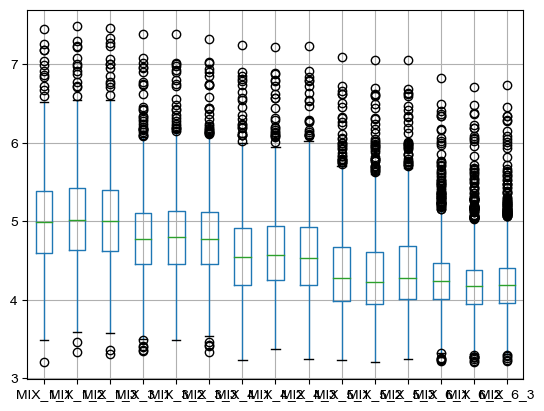

In [42]:
dfhei.boxplot()
plt.show()

In [15]:
#wo_df=df_toge.sort_values(by='MIX_5_1', ascending=False)

In [31]:
#get_areadf(df=df_2).sort_values(by='MIX_5_1', ascending=False)

In [33]:
df_toge=pd.concat([get_areadf(df=df_13),get_areadf(df=df_14),get_areadf(df=df_15),get_areadf(df=df_16)])

In [46]:
dfdf = df_toge[~(df_toge < 3.0).any(axis=1)]

In [47]:
dfdf

,MIX_1_1,MIX_1_2,MIX_1_3,MIX_3_1,MIX_3_2,MIX_3_3,MIX_4_1,MIX_4_2,MIX_4_3,MIX_5_1,MIX_5_2,MIX_5_3,MIX_6_1,MIX_6_2,MIX_6_3
mz,,,,,,,,,,,,,,,
641.40084,4.741703,4.763053,4.710117,4.092370,4.211654,4.269513,3.887505,3.966189,3.966845,3.762978,3.728516,3.724931,3.820530,3.794906,3.777064
641.47763,3.593950,3.010724,3.749582,3.602819,3.806926,3.482731,3.492900,3.344196,3.224533,3.278982,3.200303,3.410440,3.625210,3.677881,3.659155
643.41559,5.034227,5.011147,5.037028,4.607884,4.583426,4.601408,4.263873,4.327972,4.251151,3.976075,3.936614,3.932930,3.892150,3.844042,3.878752
643.45662,3.723209,3.984572,3.883605,3.656864,3.979912,3.930796,3.701827,3.833338,3.626546,3.689131,3.641177,3.680336,3.874482,3.815113,3.820595
644.33719,5.129045,5.127753,5.107210,4.636087,4.669875,4.657629,4.425371,4.409933,4.380934,4.075912,4.011570,4.153205,3.609914,3.626238,3.638090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783.44081,5.461499,5.498862,5.475235,4.879268,4.906927,4.906874,4.536432,4.561459,4.553398,4.185259,4.219060,4.215373,3.750045,3.843793,3.808818
783.95053,4.133539,4.083861,4.397592,4.056142,4.254306,4.071514,4.020361,4.015779,3.895644,3.561698,3.345178,3.521530,3.208441,3.218273,3.070038
787.67757,3.681693,3.005609,3.721646,3.848374,3.664830,3.915083,3.378580,3.739177,3.443263,3.376759,3.239550,3.381656,3.390935,3.839981,3.314499


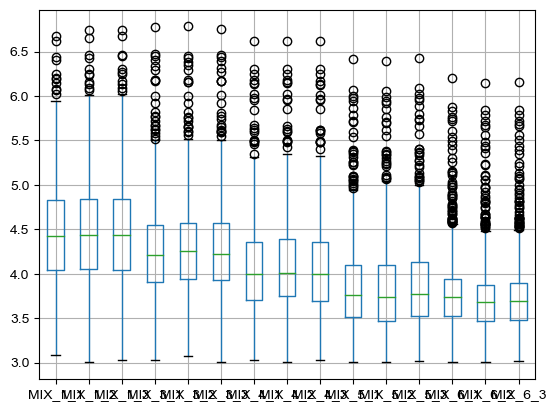

In [48]:
dfdf.boxplot()
plt.show()

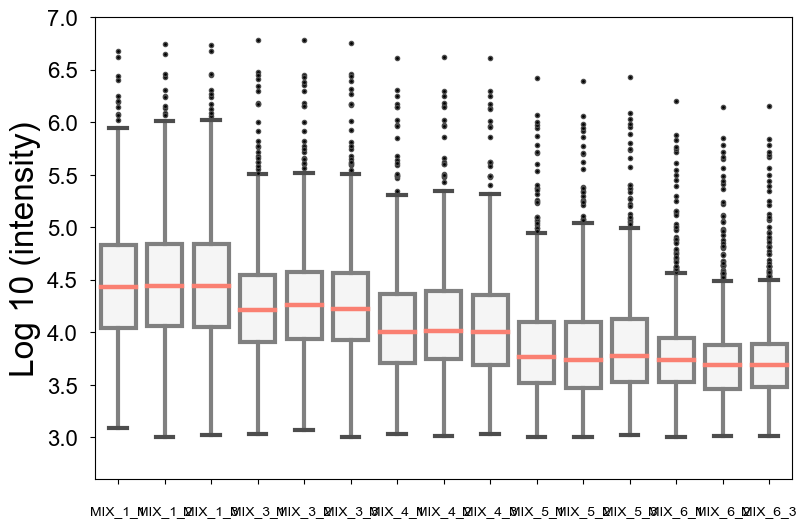

In [53]:
matplotlib.rcParams['font.family'] = "Arial"
plt.figure(figsize=(9, 6))
sns.boxplot(data=dfdf, orient='v',color="grey", boxprops=dict(facecolor="whitesmoke",edgecolor='grey',linewidth=3), 
            whiskerprops=dict(color="grey",linewidth=3), medianprops=dict(color="salmon",linewidth=3.2), width=0.75,fliersize=6,
           flierprops=dict(markerfacecolor="black", marker="."),linewidth=3)
#plt.rc('xtick', labelsize=12, fontfamily='Arial')
#plt.rc('ytick', labelsize=12, fontfamily='Arial')
plt.ylabel('Log 10 (intensity)',fontsize=24)
plt.tick_params(axis='x', which='major', pad=15)
plt.tick_params(axis='y', which='major', pad=9)
plt.xticks(fontsize=10)
plt.yticks(fontsize=16)
plt.ylim(2.6,7)
#plt.savefig('D:\\project7_SMAD\\quantification assessment\\all_common_meta.tiff', dpi=600)
plt.show()

In [420]:
wo_df=df_toge.sort_values(by='MIX_5_1', ascending=False)


In [421]:
wo_df

,MIX_1_1,MIX_1_2,MIX_1_3,MIX_3_1,MIX_3_2,MIX_3_3,MIX_4_1,MIX_4_2,MIX_4_3,MIX_5_1,MIX_5_2,MIX_5_3,MIX_6_1,MIX_6_2,MIX_6_3
mz,,,,,,,,,,,,,,,
760.58438,6.677333,6.741467,6.740600,6.781253,6.783403,6.758609,6.616790,6.623456,6.614792,6.421110,6.393575,6.432488,6.207096,6.145196,6.157154
786.60036,6.405005,6.432328,6.447623,6.477700,6.454692,6.460296,6.302980,6.301681,6.302114,6.071514,6.055760,6.089905,5.830525,5.782329,5.781971
806.56913,6.444513,6.463893,6.462398,6.454540,6.427648,6.436799,6.246991,6.252610,6.246499,6.005181,5.988024,6.028164,5.767823,5.721316,5.720903
758.56913,6.253338,6.309417,6.307068,6.343999,6.351989,6.317436,6.178401,6.181844,6.172895,5.974327,5.942603,5.979548,5.743039,5.669596,5.691081
732.55356,6.195069,6.247482,6.243782,6.294025,6.294466,6.267172,6.150142,6.158664,6.140194,5.942256,5.916927,5.953131,5.715251,5.649335,5.667173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699.31512,3.968249,3.961706,3.434090,3.370698,3.515079,3.499412,3.129368,3.371806,3.132900,2.315760,2.695569,2.860757,2.557026,2.606489,2.927935
782.37616,3.499550,3.764251,3.670060,2.743118,2.746634,3.537063,2.678791,3.005181,2.291813,2.297323,2.513750,2.525951,2.954532,2.731105,2.832381
668.17728,3.704922,3.551206,2.857935,3.071514,3.173186,3.017451,3.054996,3.247237,2.990294,2.228913,2.537189,2.694693,2.932372,2.902384,2.982588


In [426]:
wowo=wo_df.loc[wo_df['MIX_5_1']>4]

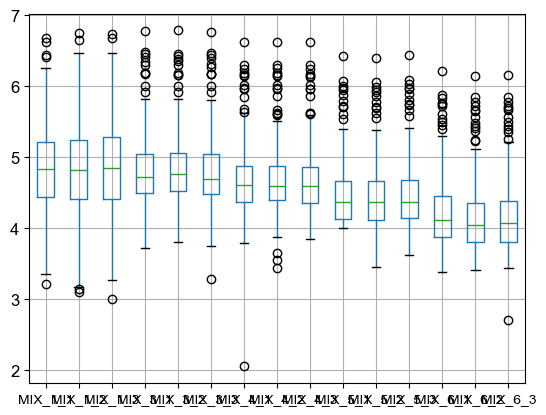

In [427]:
wowo.boxplot()
plt.show()

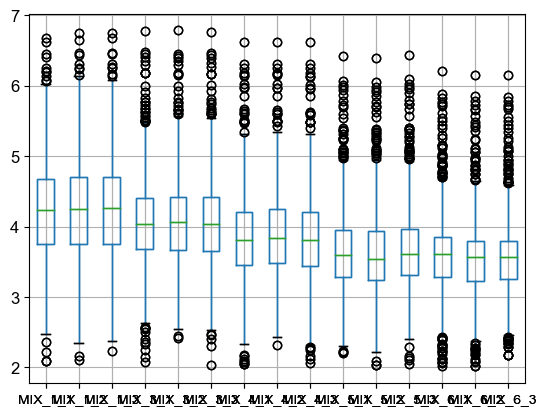

In [379]:
df_toge.boxplot()
plt.show()